In [1]:
model_id    = "lgbm_solusdt_l_fw60_2101_2605"
feature_key = "selected"


In [2]:
# Parameters
model_id = "lgbm_solusdt_l_fw60_2101_2605"
feature_key = "top10"


In [3]:
%matplotlib inline
import json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import Markdown, display

sys.path.insert(0, str(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()) / "src"))
import utils

models_cfg   = utils.load_models_config()
meta         = models_cfg["models"][model_id]
artifact_dir = Path(utils._resolve_path(meta["artifact_dir"]))
search_dir   = artifact_dir / ("search" if feature_key == "selected" else f"search_{feature_key}")

trials_path  = search_dir / "search_trials.jsonl"
best_path    = search_dir / "search_best.json"
prune_path   = search_dir / "pruning_report.json"

trials = [json.loads(l) for l in trials_path.read_text(encoding="utf-8").splitlines() if l.strip()]
best   = json.loads(best_path.read_text(encoding="utf-8"))

df = pd.DataFrame(trials)
df = df[df["objective_score"].notna()].reset_index(drop=True)

has_prune = prune_path.exists()
if has_prune:
    prune = json.loads(prune_path.read_text(encoding="utf-8"))

BLUE  = "#2E86AB"
RED   = "#E63946"
GREEN = "#52B788"
GRAY  = "#888888"

matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 9})


In [4]:
display(Markdown(f"**Model:** `{model_id}`  |  **Features:** `{feature_key}` ({len(df.iloc[0]['params']) if len(df) else '?'} params searched)  |  **Trials:** {len(df)}  |  **Loss:** quantile α=0.925"))


**Model:** `lgbm_solusdt_l_fw60_2101_2605`  |  **Features:** `top10` (13 params searched)  |  **Trials:** 60  |  **Loss:** quantile α=0.925

In [5]:
best_ratio  = best.get("valid_ratio_p925", float("nan"))
best_trial  = best.get("trial_no", "?")
best_gap    = best.get("train_valid_gap", float("nan"))
best_rho    = best.get("spearman_rho", float("nan"))
best_mono   = best.get("decile_monotonicity", float("nan"))
best_iter   = best.get("best_iteration", "?")

rows = [
    ("Best trial №",          best_trial),
    ("**valid_ratio_p925**",  f"**{best_ratio:.4f}**"),
    ("train_ratio_p925",      f"{best.get('train_ratio_p925', float('nan')):.4f}"),
    ("Train–valid gap",       f"{best_gap:.4f}"),
    ("Spearman ρ (valid)",    f"{best_rho:.4f}"),
    ("Decile monotonicity",   f"{best_mono:.3f}"),
    ("Best iteration",        best_iter),
]
if has_prune:
    rows += [
        ("Features (selected)",   prune["n_selected"]),
        ("Zero-split removed",    prune["n_zero_split"]),
        ("Features (pruned)",     prune["n_pruned_selected"]),
    ]

display(Markdown("## Összefoglalás"))
tbl = pd.DataFrame(rows, columns=["Metric", "Value"])
display(Markdown(tbl.to_markdown(index=False)))


## Összefoglalás

| Metric               | Value      |
|:---------------------|:-----------|
| Best trial №         | 1          |
| **valid_ratio_p925** | **1.9421** |
| train_ratio_p925     | 1.9891     |
| Train–valid gap      | 0.0470     |
| Spearman ρ (valid)   | 0.2523     |
| Decile monotonicity  | 1.000      |
| Best iteration       | 758        |
| Features (selected)  | 10         |
| Zero-split removed   | 0          |
| Features (pruned)    | 10         |

## Trial Progressz

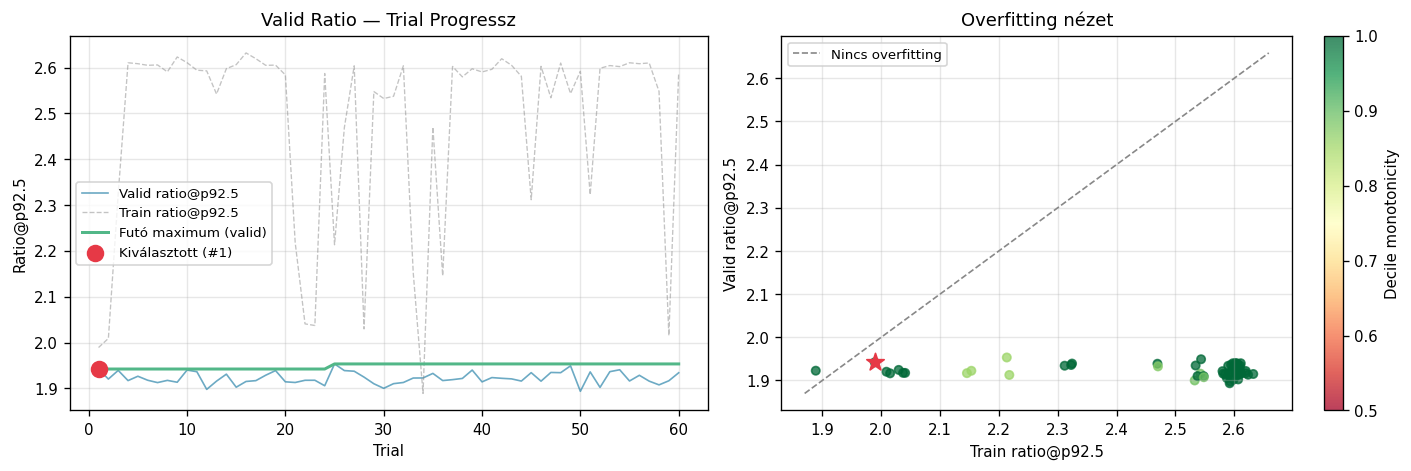

In [6]:
display(Markdown("## Trial Progressz"))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: valid ratio over trials with running best
ax = axes[0]
ax.plot(df["trial_no"], df["valid_ratio_p925"], color=BLUE, lw=1.0, alpha=0.7, label="Valid ratio@p92.5")
ax.plot(df["trial_no"], df["train_ratio_p925"], color=GRAY, lw=0.8, alpha=0.5, ls="--", label="Train ratio@p92.5")
running_best = df["valid_ratio_p925"].cummax()
ax.plot(df["trial_no"], running_best, color=GREEN, lw=1.8, label="Futó maximum (valid)")
brow = df[df["trial_no"] == best_trial]
if len(brow):
    ax.scatter(brow["trial_no"], brow["valid_ratio_p925"], color=RED, s=90, zorder=5, label=f"Kiválasztott (#{best_trial})")
ax.set_xlabel("Trial")
ax.set_ylabel("Ratio@p92.5")
ax.set_title("Valid Ratio — Trial Progressz")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Right: train vs valid scatter colored by decile_monotonicity
ax = axes[1]
sc = ax.scatter(df["train_ratio_p925"], df["valid_ratio_p925"],
                c=df["decile_monotonicity"].clip(0.5, 1.0),
                cmap="RdYlGn", vmin=0.5, vmax=1.0, s=25, alpha=0.75)
plt.colorbar(sc, ax=ax, label="Decile monotonicity")
lo = min(df["train_ratio_p925"].min(), df["valid_ratio_p925"].min()) * 0.99
hi = max(df["train_ratio_p925"].max(), df["valid_ratio_p925"].max()) * 1.01
ax.plot([lo, hi], [lo, hi], "--", color=GRAY, lw=1, label="Nincs overfitting")
if len(brow):
    ax.scatter(brow["train_ratio_p925"], brow["valid_ratio_p925"], color=RED, s=120, zorder=5, marker="*")
ax.set_xlabel("Train ratio@p92.5")
ax.set_ylabel("Valid ratio@p92.5")
ax.set_title("Overfitting nézet")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
display(Markdown("## Top 10 Trial"))
cols = ["trial_no", "valid_ratio_p925", "train_ratio_p925", "train_valid_gap",
        "spearman_rho", "decile_monotonicity", "valid_rmse", "best_iteration", "elapsed_s"]
avail = [c for c in cols if c in df.columns]
top10 = df.nlargest(10, "valid_ratio_p925")[avail].copy()
top10.index = range(1, len(top10)+1)
display(Markdown(top10.round(4).to_markdown()))


## Top 10 Trial

|    |   trial_no |   valid_ratio_p925 |   train_ratio_p925 |   train_valid_gap |   spearman_rho |   decile_monotonicity |   valid_rmse |   best_iteration |   elapsed_s |
|---:|-----------:|-------------------:|-------------------:|------------------:|---------------:|----------------------:|-------------:|-----------------:|------------:|
|  1 |         25 |             1.9532 |             2.2134 |            0.2602 |         0.2635 |                0.8571 |       0.0107 |              336 |         1   |
|  2 |         49 |             1.9491 |             2.5436 |            0.5945 |         0.2776 |                1      |       0.0105 |              285 |         0.9 |
|  3 |          1 |             1.9421 |             1.9891 |            0.047  |         0.2523 |                1      |       0.0112 |              758 |         1.2 |
|  4 |         54 |             1.9405 |             2.6024 |            0.6619 |         0.2914 |                1      |       0.0101 |             1053 |         2.2 |
|  5 |         10 |             1.9398 |             2.611  |            0.6712 |         0.293  |                1      |       0.0101 |              548 |         1.3 |
|  6 |         39 |             1.9398 |             2.5977 |            0.6579 |         0.2927 |                1      |       0.01   |              950 |         2   |
|  7 |          3 |             1.9391 |             2.3243 |            0.3852 |         0.2675 |                1      |       0.0106 |              975 |         1.9 |
|  8 |         19 |             1.9387 |             2.6056 |            0.6669 |         0.2917 |                1      |       0.01   |              434 |         1.2 |
|  9 |         26 |             1.9387 |             2.4694 |            0.5307 |         0.2764 |                1      |       0.0105 |              283 |         0.8 |
| 10 |         27 |             1.9373 |             2.6041 |            0.6668 |         0.2913 |                1      |       0.0101 |              585 |         1.4 |

In [8]:
display(Markdown("## Best Hyperparaméterek"))
params = best.get("params", {})
rows_p = [{"Paraméter": k, "Érték": v} for k, v in sorted(params.items())]
display(Markdown(pd.DataFrame(rows_p).to_markdown(index=False)))


## Best Hyperparaméterek

| Paraméter         |          Érték |
|:------------------|---------------:|
| colsample_bytree  |    0.532545    |
| extra_trees       |    1           |
| learning_rate     |    0.0167389   |
| max_bin           |   63           |
| max_depth         |   -1           |
| min_child_samples | 7159           |
| min_child_weight  |    0.0314288   |
| min_split_gain    |    1.20875e-05 |
| num_leaves        |    8           |
| path_smooth       |    0.280164    |
| reg_alpha         |    0.00706897  |
| reg_lambda        |    2.3102      |
| subsample         |    0.541702    |

## Paraméter Hatás (valid_ratio@p92.5)

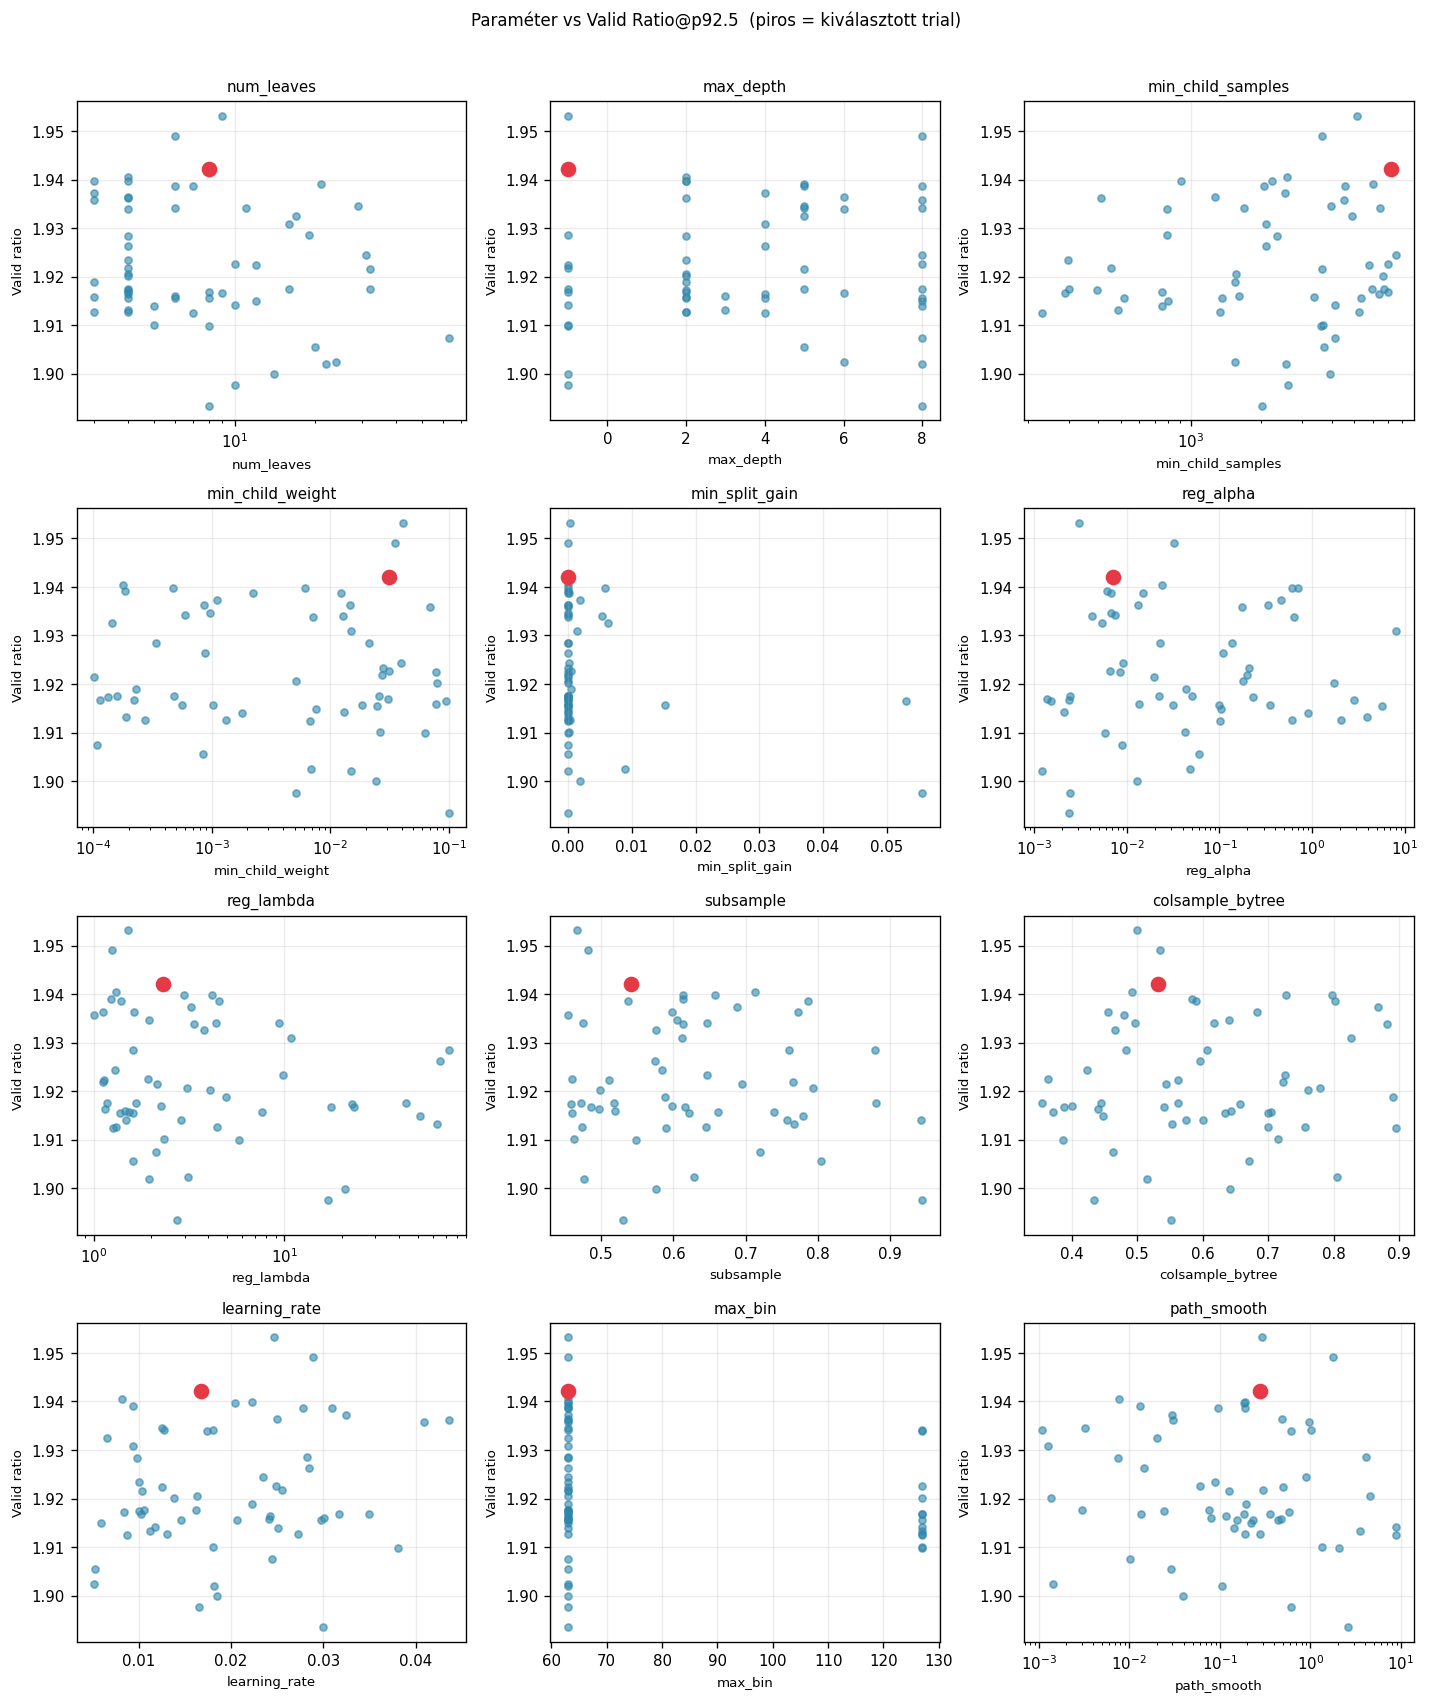

In [9]:
display(Markdown("## Paraméter Hatás (valid_ratio@p92.5)"))
first_params = df["params"].dropna().iloc[0] if len(df) > 0 else {}
float_params = [k for k, v in (first_params or {}).items() if isinstance(v, (int, float)) and not isinstance(v, bool)]
n_fp = len(float_params)
if n_fp > 0:
    ncols = 3
    nrows = (n_fp + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.5 * nrows), squeeze=False)
    for i, p in enumerate(float_params):
        ax = axes[i // ncols][i % ncols]
        vals = df["params"].apply(lambda d: d.get(p) if isinstance(d, dict) else None).astype(float)
        ax.scatter(vals, df["valid_ratio_p925"], s=18, alpha=0.6, color=BLUE)
        ax.scatter([params.get(p)], [best_ratio], color=RED, s=70, zorder=5)
        ax.set_xlabel(p, fontsize=8)
        ax.set_ylabel("Valid ratio", fontsize=8)
        ax.set_title(p, fontsize=9)
        ax.grid(alpha=0.25)
        if vals.dropna().min() > 0 and vals.dropna().max() / vals.dropna().min() > 10:
            ax.set_xscale("log")
    for j in range(i + 1, nrows * ncols):
        axes[j // ncols][j % ncols].set_visible(False)
    plt.suptitle("Paraméter vs Valid Ratio@p92.5  (piros = kiválasztott trial)", y=1.01, fontsize=10)
    plt.tight_layout()
    plt.show()


## Feature Importance (Post-Prune)

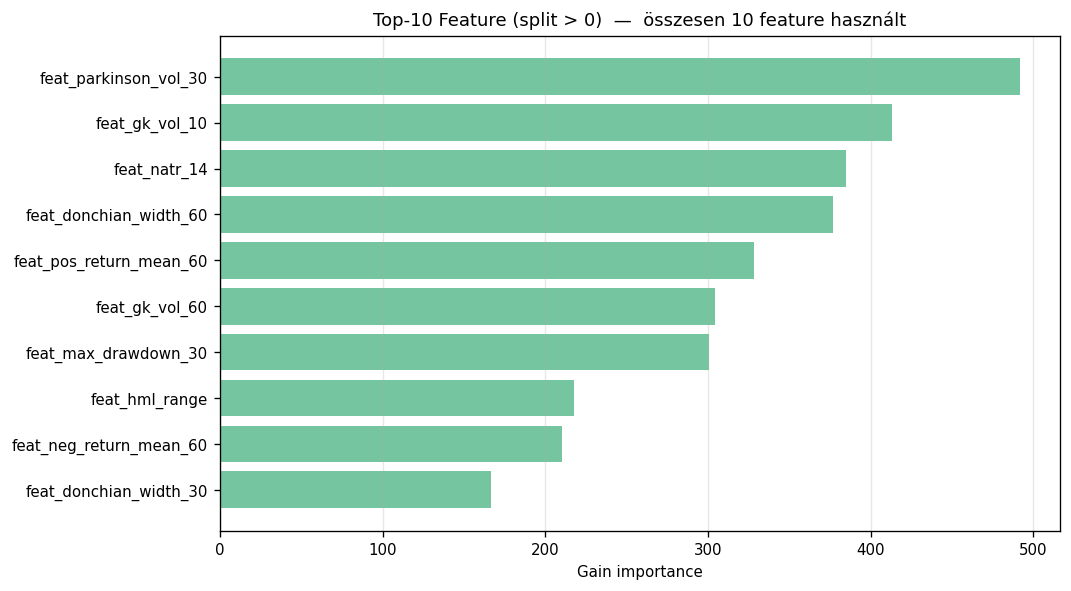

**Nincs zero-split feature** — mind a 10 selected feature részt vett legalább egy vágásban a best params modellben.

In [10]:
display(Markdown("## Feature Importance (Post-Prune)"))
if has_prune:
    fi_df = pd.DataFrame(prune["all_feature_importance"])
    used  = fi_df[fi_df["split"] > 0].head(30).copy()
    used["gain_norm"] = used["gain"] / used["gain"].max()

    fig, ax = plt.subplots(figsize=(9, max(5, len(used) * 0.30)))
    bars = ax.barh(used["feature"][::-1], used["gain"][::-1], color=GREEN, alpha=0.8)
    ax.set_xlabel("Gain importance")
    ax.set_title(f"Top-{len(used)} Feature (split > 0)  —  összesen {prune['n_pruned_selected']} feature használt")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    if prune["zero_split_features"]:
        display(Markdown(
            f"**Zero-split (eltávolítva, {prune['n_zero_split']} db):** "
            + ", ".join(f"`{f}`" for f in sorted(prune["zero_split_features"]))
        ))
    else:
        display(Markdown(
            f"**Nincs zero-split feature** — mind a {prune['n_selected']} selected feature "
            "részt vett legalább egy vágásban a best params modellben."
        ))
else:
    display(Markdown("_Pruning report hiányzik. Futtasd `run_prune()` a search után._"))


## Learning Curve (Best Trial)

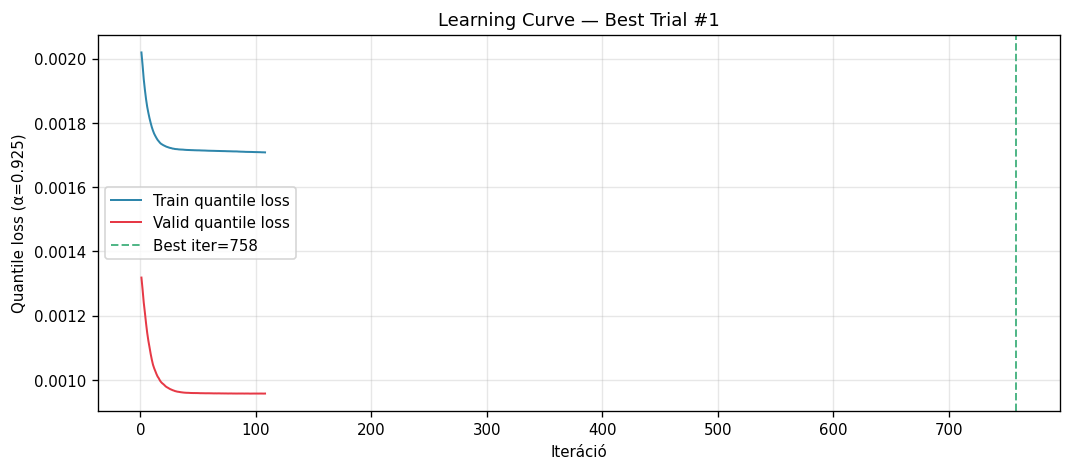

In [11]:
display(Markdown("## Learning Curve (Best Trial)"))
curve_path = search_dir / "trial_curves" / f"trial_{int(best_trial):04d}.json"
if curve_path.exists():
    curve = json.loads(curve_path.read_text(encoding="utf-8"))
    train_loss = curve.get("train", {}).get("quantile", [])
    valid_loss = curve.get("valid", {}).get("quantile", [])
    if train_loss and valid_loss:
        iters = list(range(1, len(train_loss) + 1))
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.plot(iters, train_loss, color=BLUE, lw=1.2, label="Train quantile loss")
        ax.plot(iters, valid_loss, color=RED,  lw=1.2, label="Valid quantile loss")
        best_it = best.get("best_iteration")
        if best_it:
            ax.axvline(best_it, color=GREEN, lw=1.2, ls="--", label=f"Best iter={best_it}")
        ax.set_xlabel("Iteráció")
        ax.set_ylabel("Quantile loss (α=0.925)")
        ax.set_title(f"Learning Curve — Best Trial #{best_trial}")
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    display(Markdown(f"_Learning curve nem található: {curve_path}_"))
